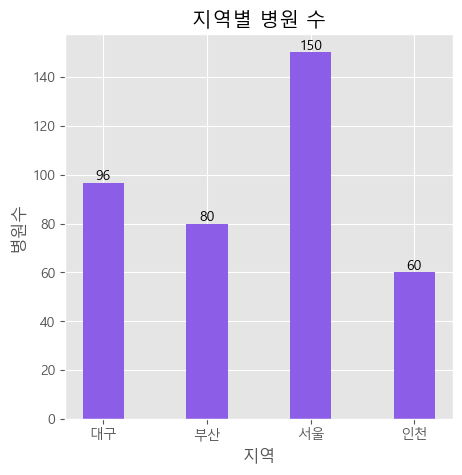

In [33]:
import pandas as pd
# matplotlib : 메트플롯 반드시 import 한다
import matplotlib.pyplot as plt

# 데이터 생성
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [10000000, 3000000, 2000000]
})
df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 전처리를 위해 merge
# outer 로 병합하면 df1과 df2가 합집합된다
merged = pd.merge(df1, df2, on="지역", how= "outer")
# merged

# 결측치 처리
# 결측치는 병원수와 총인구의 평균으로 정의한다
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged

# -------------------------------------------

# 세로 막대 그래프 만들기 : plt.bar
# x축 : 지역 / y축 : 병원수

# 반드시 한글 꺠짐현상 코드를 삽입한다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 차트 배경 + 색상 자동으로 그리도에 빨간색으로 지정
# plt.style.use('ggplot')  # 한 번 적용하면 계속 적용됨 ㅋㅋ.

# 그래프 크기 지정 : figure(10, 5)
plt.figure(figsize=(5, 5))

# 세로막대 기본넓이 width=0.8
bars= plt.bar(merged['지역'], merged['병원수'], width=0.4, color='#8c5ee8')

# 차트제목 : title / x축 제목 : xlabel / y축 제목 :ylabel
plt.title('지역별 병원 수')
plt.xlabel('지역')
plt.ylabel('병원수')

# 각 막대의 데이터 레이블 값 출력하는 방법
for bar in bars:
    height = bar.get_height()  # 막내 높이(값) 예) 대구 : 96
    # 막대그래프 넓이 시작점 추출 : get_x
    # 막대그래프 넓이 추출 : get_width
    # / 2 : 가운데정렬
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height, 
        f'{int(height)}', 
        ha='center',
        va='bottom'
    )

# 저장먼저
plt.savefig('hospital_chrt.pdf', dpi=300)

# 그래프 출력
plt.show()